# 01 数据下载与预处理

本 Notebook 完成：
- 下载 5 只 A 股股票与沪深300指数历史行情
- 计算日对数收益率
- 描述性统计与 Jarque-Bera 正态性检验
- 输出收益率时序图

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
from scipy.stats import jarque_bera
import akshare as ak

plt.style.use('seaborn-v0_8')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)

def setup_chinese_font():
    candidates = ['PingFang SC', 'Heiti SC', 'STHeiti', 'Songti SC', 'Arial Unicode MS', 'Noto Sans CJK SC', 'WenQuanYi Zen Hei', 'SimHei', 'Microsoft YaHei']
    installed = {f.name for f in font_manager.fontManager.ttflist}
    available = [name for name in candidates if name in installed]
    if available:
        plt.rcParams['font.sans-serif'] = available + ['DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False

setup_chinese_font()

In [2]:
BASE_DIR = Path.cwd()
RAW_DIR = BASE_DIR / 'data_raw'
CLEAN_DIR = BASE_DIR / 'data_clean'
OUT_DIR = BASE_DIR / 'output'

RAW_DIR.mkdir(exist_ok=True)
CLEAN_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

START_DATE = '2019-01-01'
END_DATE = pd.Timestamp.today().strftime('%Y-%m-%d')
RISK_FREE_ANNUAL = 0.025
RISK_FREE_DAILY = RISK_FREE_ANNUAL / 252

STOCKS = [
    {'symbol': '600036', 'name': '招商银行', 'industry': '银行'},
    {'symbol': '600519', 'name': '贵州茅台', 'industry': '消费'},
    {'symbol': '002475', 'name': '立讯精密', 'industry': '科技'},
    {'symbol': '600276', 'name': '恒瑞医药', 'industry': '医药'},
    {'symbol': '601088', 'name': '中国神华', 'industry': '能源'},
]

if len(STOCKS) != 5:
    raise ValueError('请先在 STOCKS 中填写 5 只股票：symbol/name/industry，例如 600036。')

stock_meta = pd.DataFrame(STOCKS)
stock_meta

,symbol,name,industry
0,600036,招商银行,银行
1,600519,贵州茅台,消费
2,002475,立讯精密,科技
3,600276,恒瑞医药,医药
4,601088,中国神华,能源


In [3]:
def fetch_stock_close(symbol: str) -> pd.DataFrame:
    df = ak.stock_zh_a_hist(symbol=symbol, period='daily', start_date='20190101', end_date=pd.Timestamp.today().strftime('%Y%m%d'), adjust='hfq')
    if df is None or df.empty:
        raise ValueError(f'未获取到个股数据: {symbol}')
    df = df.rename(columns={'日期': 'date', '收盘': 'close'})
    df['date'] = pd.to_datetime(df['date'])
    df = df[['date', 'close']].dropna().sort_values('date')
    return df

def fetch_hs300_close() -> pd.DataFrame:
    idx = ak.index_zh_a_hist(symbol='000300', period='daily', start_date='20190101', end_date=pd.Timestamp.today().strftime('%Y%m%d'))
    if idx is None or idx.empty:
        raise ValueError('未获取到沪深300指数数据')
    idx = idx.rename(columns={'日期': 'date', '收盘': 'close'})
    idx['date'] = pd.to_datetime(idx['date'])
    idx = idx[['date', 'close']].dropna().sort_values('date')
    return idx

In [4]:
close_frames = []

for row in STOCKS:
    symbol = row['symbol']
    df = fetch_stock_close(symbol)
    df.to_csv(RAW_DIR / f'stock_{symbol}.csv', index=False, encoding='utf-8-sig')
    close_frames.append(df.rename(columns={'close': symbol}).set_index('date'))

hs300 = fetch_hs300_close()
hs300.to_csv(RAW_DIR / 'index_000300.csv', index=False, encoding='utf-8-sig')
close_frames.append(hs300.rename(columns={'close': 'HS300'}).set_index('date'))

close_prices = pd.concat(close_frames, axis=1, join='inner').sort_index()
close_prices = close_prices.loc[(close_prices.index >= START_DATE) & (close_prices.index <= END_DATE)]

log_returns = np.log(close_prices / close_prices.shift(1)).dropna()

close_prices.to_csv(CLEAN_DIR / 'close_prices.csv', encoding='utf-8-sig')
log_returns.to_csv(CLEAN_DIR / 'log_returns.csv', encoding='utf-8-sig')
stock_meta.to_csv(CLEAN_DIR / 'stock_meta.csv', index=False, encoding='utf-8-sig')
pd.DataFrame({'risk_free_annual': [RISK_FREE_ANNUAL], 'risk_free_daily': [RISK_FREE_DAILY]}).to_csv(CLEAN_DIR / 'risk_free_rate.csv', index=False, encoding='utf-8-sig')

close_prices.head(), log_returns.head()

  0%|          | 0/17 [00:00<?, ?it/s]

(            600036   600519  002475   600276  601088    HS300
 date                                                         
 2019-01-02  108.45  3239.61  277.26  1456.63   27.40  2969.54
 2019-01-03  109.66  3194.49  263.91  1404.87   27.32  2964.84
 2019-01-04  112.13  3254.79  259.26  1494.22   27.70  3035.87
 2019-01-07  112.16  3272.33  268.94  1472.97   27.68  3054.30
 2019-01-08  110.99  3268.81  272.81  1484.14   28.05  3047.70,
               600036    600519    002475    600276    601088     HS300
 date                                                                  
 2019-01-03  0.011095 -0.014026 -0.049348 -0.036181 -0.002924 -0.001584
 2019-01-04  0.022274  0.018700 -0.017777  0.061660  0.013813  0.023675
 2019-01-07  0.000268  0.005375  0.036657 -0.014324 -0.000722  0.006052
 2019-01-08 -0.010486 -0.001076  0.014287  0.007555  0.013279 -0.002163
 2019-01-09  0.016797  0.017266  0.005666  0.028057  0.001781  0.010049)

In [5]:
stats_rows = []

for col in log_returns.columns:
    series = log_returns[col].dropna()
    jb_stat, jb_pvalue = jarque_bera(series.values)
    stats_rows.append({
        'asset': col,
        'mean': series.mean(),
        'std': series.std(ddof=1),
        'skew': series.skew(),
        'kurtosis': series.kurtosis(),
        'jb_stat': jb_stat,
        'jb_pvalue': jb_pvalue,
        'n_obs': series.shape[0]
    })

descriptive_stats = pd.DataFrame(stats_rows).sort_values('asset').reset_index(drop=True)
descriptive_stats.to_csv(OUT_DIR / 'descriptive_stats.csv', index=False, encoding='utf-8-sig')
descriptive_stats

,asset,mean,std,skew,kurtosis,jb_stat,jb_pvalue,n_obs
0,002475,0.001043,0.028456,0.143726,1.012429,79.410099,5.705795e-18,1741
1,600036,0.000387,0.014688,0.246754,3.133733,724.373386,5.061949e-158,1741
2,600276,0.000326,0.020519,0.156495,2.621183,501.337335,1.367669e-109,1741
3,600519,0.000556,0.016563,0.224341,3.059407,688.151754,3.713174e-150,1741
4,601088,0.000552,0.011662,0.288075,3.385635,849.097620,4.176326e-185,1741
5,HS300,0.000244,0.012038,-0.190962,5.824313,2454.362735,0.000000e+00,1741


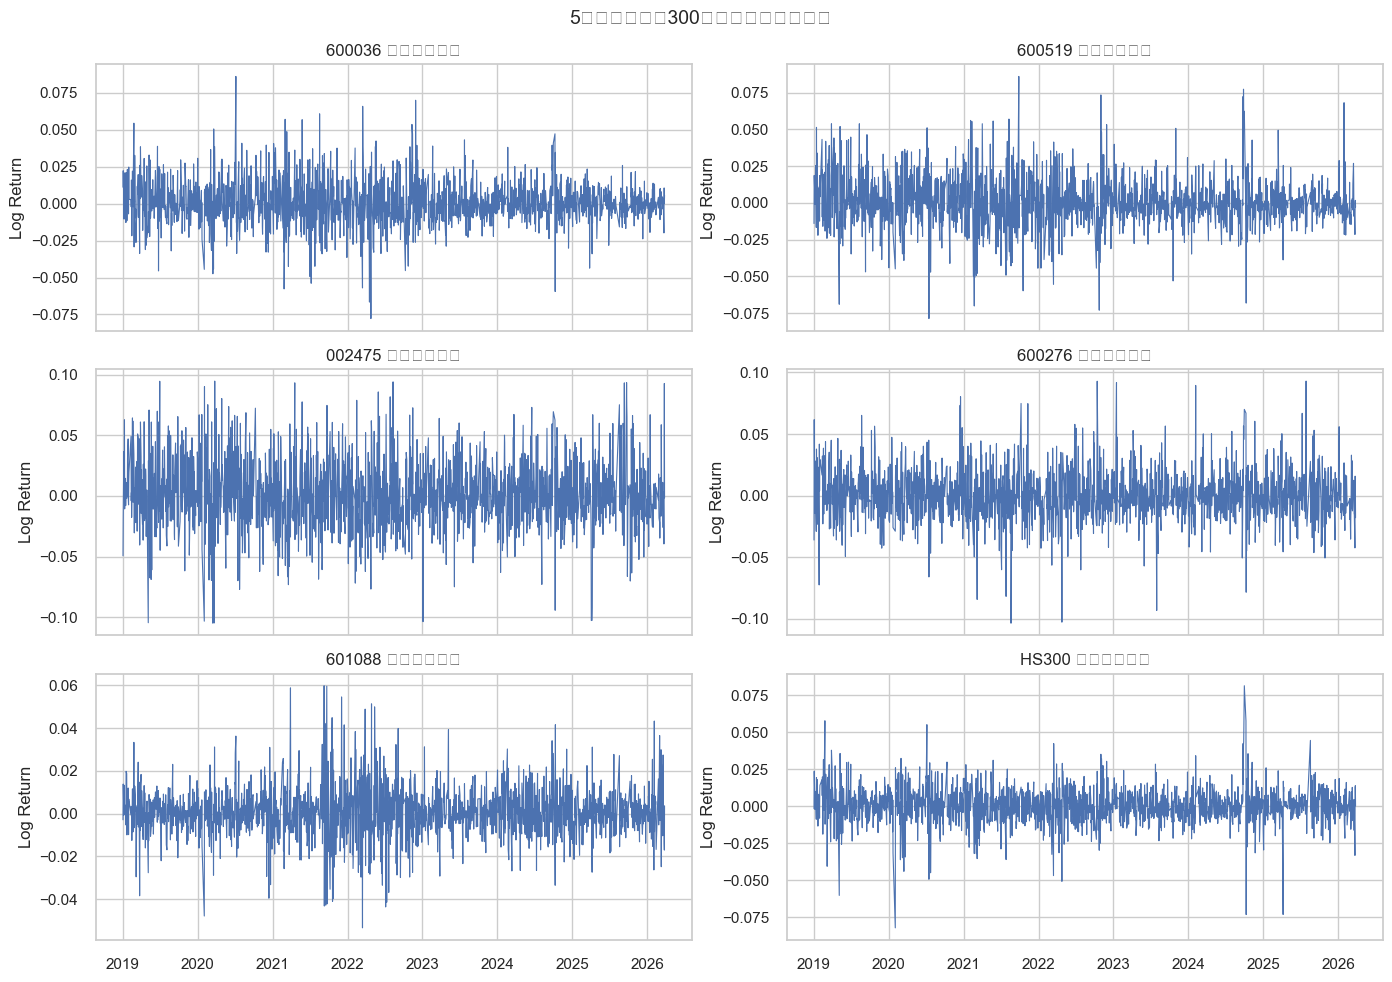

In [6]:
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 10), sharex=True)
axes = axes.flatten()

for i, col in enumerate(log_returns.columns):
    axes[i].plot(log_returns.index, log_returns[col], linewidth=0.8)
    axes[i].set_title(f'{col} 日对数收益率')
    axes[i].set_ylabel('Log Return')

for j in range(len(log_returns.columns), len(axes)):
    axes[j].axis('off')

fig.suptitle('5只股票与沪深300日对数收益率时序图', fontsize=14)
fig.tight_layout()
fig.savefig(OUT_DIR / 'returns_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

## 简要结论（填写建议）

- 对照 `descriptive_stats.csv` 总结不同股票收益分布差异。
- 重点观察偏度、峰度和 JB 检验 p 值，判断正态性是否成立。
- 对波动更高的标的给出行业与阶段性解释。